**Parcial #1**

Emanuel Antonio Puentes Erazo 

A00410253

Para cada pregunta deje un codigo estan en orden como me aparecieron en el smaan, hubieron algunos codigos que repeti, pero fue para seguir el orden de las preguntas.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Estilo visual global ---
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

# --- Silenciar warnings menores ---
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas correctamente")
print(f"   Pandas   : {pd.__version__}")
print(f"   NumPy    : {np.__version__}")
print(f"   Seaborn  : {sns.__version__}")

✅ Librerías cargadas correctamente
   Pandas   : 3.0.3
   NumPy    : 2.4.6
   Seaborn  : 0.13.2


In [2]:
df = pd.read_csv("dataset_futbol_jugadores.csv")

In [4]:
df.shape

(150, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          150 non-null    int64  
 1   Jugador                     150 non-null    str    
 2   Equipo                      150 non-null    str    
 3   Posicion                    150 non-null    str    
 4   Nacionalidad                147 non-null    str    
 5   Edad                        150 non-null    int64  
 6   Partidos_Jugados            150 non-null    int64  
 7   Goles                       150 non-null    int64  
 8   Asistencias                 141 non-null    float64
 9   Minutos_Jugados             150 non-null    int64  
 10  Tarjetas_Amarillas          150 non-null    int64  
 11  Tarjetas_Rojas              150 non-null    int64  
 12  Altura_cm                   150 non-null    int64  
 13  Peso_kg                     150 non-null    in

In [6]:
df.describe()

,ID,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
count,150.000000,150.000000,150.000000,150.000000,141.000000,150.000000,150.000000,150.000000,150.000000,150.000000,145.000000,144.000000
mean,75.500000,28.053333,19.586667,3.940000,3.007092,1283.953333,3.013333,0.226667,179.513333,75.360000,6.829034,7.825417
std,43.445368,7.271150,11.156716,4.338419,1.758638,796.460107,1.404626,0.420078,6.629947,7.111084,0.599229,14.728567
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163.000000,60.000000,5.540000,0.300000
25%,38.250000,22.000000,12.000000,1.000000,2.000000,712.500000,2.000000,0.000000,175.000000,71.000000,6.440000,2.762500
50%,75.500000,28.000000,20.000000,3.000000,3.000000,1157.000000,3.000000,0.000000,179.000000,75.000000,6.820000,4.710000
75%,112.750000,34.000000,29.000000,6.000000,4.000000,1900.500000,4.000000,0.000000,184.000000,81.000000,7.210000,8.882500
max,150.000000,40.000000,38.000000,34.000000,9.000000,3293.000000,7.000000,1.000000,197.000000,96.000000,8.160000,129.050000


In [10]:
print(df['Posicion'].value_counts())

Posicion
Mediocampista    52
Defensa          49
Delantero        34
Portero          15
Name: count, dtype: int64


In [14]:
df['Valor_Mercado_Millones_EUR'].median()

np.float64(4.71)

In [61]:
# Seleccionamos las variables numéricas
variables_corr = ["ID", "Edad", "Partidos_Jugados",
                  "Goles", "Asistencias", "Minutos_Jugados",
                  "Tarjetas_Amarillas", "Tarjetas_Rojas", "Altura_cm", "Peso_kg", "Rating_Promedio", "Valor_Mercado_Millones_EUR"]

matriz_corr = df[variables_corr].corr(method="pearson")
matriz_corr.round(2)

,ID,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
ID,1.00,-0.05,0.01,-0.15,-0.04,0.04,-0.02,0.02,0.08,-0.05,0.09,-0.13
Edad,-0.05,1.00,-0.02,-0.15,-0.10,-0.01,-0.02,0.04,-0.02,0.03,0.05,-0.15
Partidos_Jugados,0.01,-0.02,1.00,-0.03,-0.03,0.89,-0.01,0.09,-0.01,-0.03,-0.01,0.05
Goles,-0.15,-0.15,-0.03,1.00,0.32,0.02,-0.06,0.01,0.09,-0.08,-0.13,0.60
Asistencias,-0.04,-0.10,-0.03,0.32,1.00,-0.03,0.06,-0.04,-0.12,0.06,0.05,0.25
Minutos_Jugados,0.04,-0.01,0.89,0.02,-0.03,1.00,-0.02,0.05,-0.08,-0.02,-0.05,0.10
Tarjetas_Amarillas,-0.02,-0.02,-0.01,-0.06,0.06,-0.02,1.00,-0.02,0.13,0.12,-0.10,-0.06
Tarjetas_Rojas,0.02,0.04,0.09,0.01,-0.04,0.05,-0.02,1.00,-0.09,-0.06,0.04,-0.00
Altura_cm,0.08,-0.02,-0.01,0.09,-0.12,-0.08,0.13,-0.09,1.00,0.09,0.01,-0.02
Peso_kg,-0.05,0.03,-0.03,-0.08,0.06,-0.02,0.12,-0.06,0.09,1.00,0.06,0.06


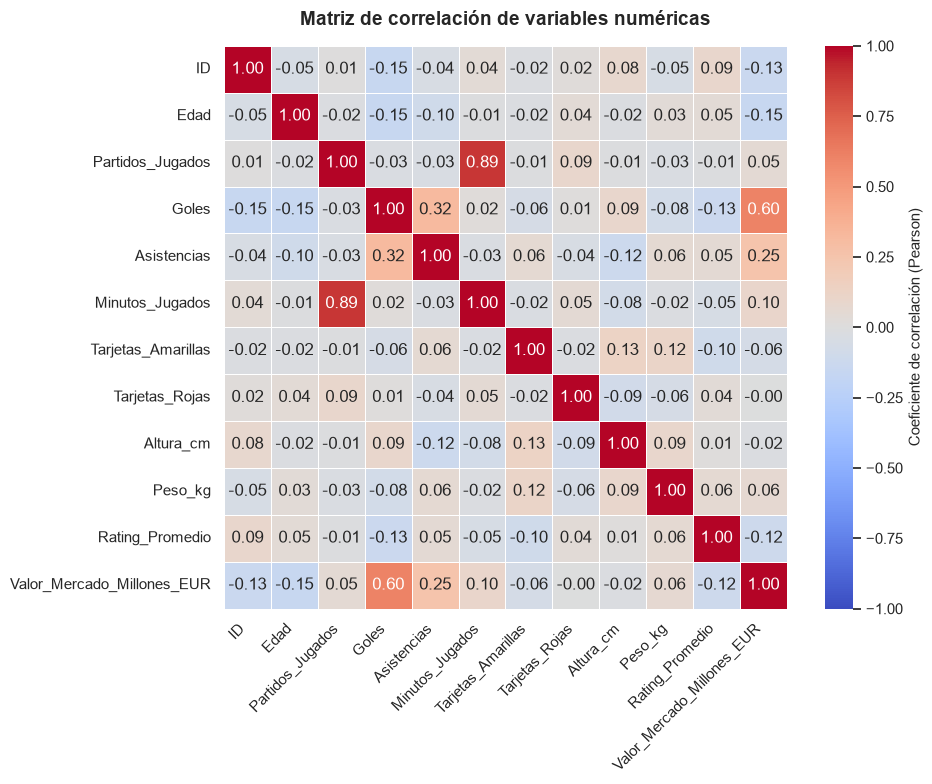

In [62]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Coeficiente de correlación (Pearson)"},
)
plt.title("Matriz de correlación de variables numéricas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [26]:
Q1 = df["Valor_Mercado_Millones_EUR"].quantile(0.25)
Q3 = df["Valor_Mercado_Millones_EUR"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos_precio = df[
    (df["Valor_Mercado_Millones_EUR"] < limite_inferior)
    | (df["Valor_Mercado_Millones_EUR"] > limite_superior)
]

print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de candidatos a atípicos:", len(atipicos_precio))


Límite inferior: -6.4174999999999995
Límite superior: 18.0625
Cantidad de candidatos a atípicos: 4


In [27]:
df.describe()

,ID,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
count,150.000000,150.000000,150.000000,150.000000,141.000000,150.000000,150.000000,150.000000,150.000000,150.000000,145.000000,144.000000
mean,75.500000,28.053333,19.586667,3.940000,3.007092,1283.953333,3.013333,0.226667,179.513333,75.360000,6.829034,7.825417
std,43.445368,7.271150,11.156716,4.338419,1.758638,796.460107,1.404626,0.420078,6.629947,7.111084,0.599229,14.728567
min,1.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163.000000,60.000000,5.540000,0.300000
25%,38.250000,22.000000,12.000000,1.000000,2.000000,712.500000,2.000000,0.000000,175.000000,71.000000,6.440000,2.762500
50%,75.500000,28.000000,20.000000,3.000000,3.000000,1157.000000,3.000000,0.000000,179.000000,75.000000,6.820000,4.710000
75%,112.750000,34.000000,29.000000,6.000000,4.000000,1900.500000,4.000000,0.000000,184.000000,81.000000,7.210000,8.882500
max,150.000000,40.000000,38.000000,34.000000,9.000000,3293.000000,7.000000,1.000000,197.000000,96.000000,8.160000,129.050000


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          150 non-null    int64  
 1   Jugador                     150 non-null    str    
 2   Equipo                      150 non-null    str    
 3   Posicion                    150 non-null    str    
 4   Nacionalidad                147 non-null    str    
 5   Edad                        150 non-null    int64  
 6   Partidos_Jugados            150 non-null    int64  
 7   Goles                       150 non-null    int64  
 8   Asistencias                 141 non-null    float64
 9   Minutos_Jugados             150 non-null    int64  
 10  Tarjetas_Amarillas          150 non-null    int64  
 11  Tarjetas_Rojas              150 non-null    int64  
 12  Altura_cm                   150 non-null    int64  
 13  Peso_kg                     150 non-null    in

**EDA**

In [29]:
faltantes = df.isna().sum()
#Suma de datos faltantes por columna en el DataFrame.
porcentaje = (df.isna().mean() * 100).round(2)

resumen_faltantes = pd.DataFrame({
    "faltantes": faltantes,
    "porcentaje": porcentaje
})

resumen_faltantes[resumen_faltantes["faltantes"] > 0]

,faltantes,porcentaje
Nacionalidad,3,2.00
Asistencias,9,6.00
Rating_Promedio,5,3.33
Valor_Mercado_Millones_EUR,6,4.00


In [32]:
print(df.duplicated().sum())

0


In [35]:
print("ID duplicados:", df["ID"].duplicated().sum())

ID duplicados: 0


In [36]:
df_limpio = df.copy()

In [37]:
df_limpio.isna().sum()[df_limpio.isna().sum() > 0]

Nacionalidad                  3
Asistencias                   9
Rating_Promedio               5
Valor_Mercado_Millones_EUR    6
dtype: int64

In [39]:
df_limpio = df_limpio.dropna(subset=["Asistencias"])

In [40]:
df_limpio["Nacionalidad"] = df_limpio["Nacionalidad"].fillna("No registrado")

In [42]:
mediana_rating = df_limpio["Rating_Promedio"].median()
df_limpio["Rating_Promedio"] = df_limpio["Rating_Promedio"].fillna(mediana_rating)

In [43]:
mediana_valor = df_limpio["Valor_Mercado_Millones_EUR"].median()
df_limpio["Valor_Mercado_Millones_EUR"] = df_limpio["Valor_Mercado_Millones_EUR"].fillna(mediana_valor)

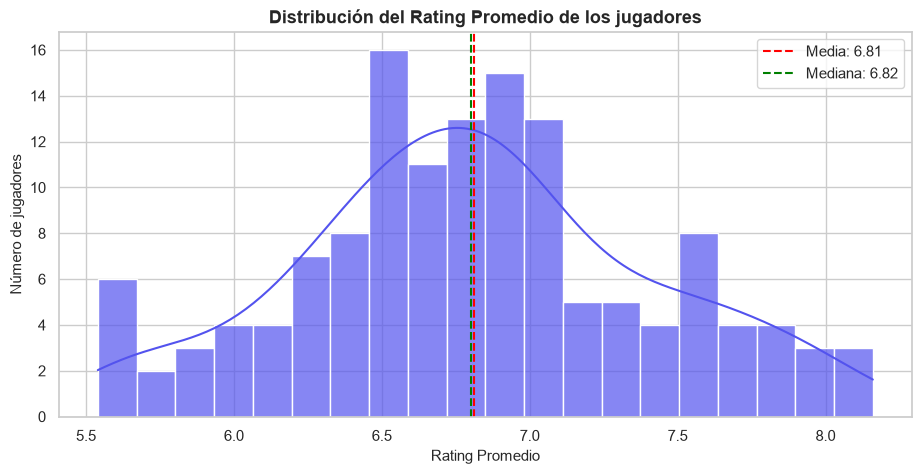

In [44]:
plt.figure(figsize=(11, 5))
sns.histplot(data=df_limpio,x="Rating_Promedio",bins=20,kde=True,color="#5353EE",alpha=0.7)
plt.title("Distribución del Rating Promedio de los jugadores")

plt.xlabel("Rating Promedio")
plt.ylabel("Número de jugadores")
plt.axvline(df_limpio["Rating_Promedio"].mean(),color="red", linestyle="--",label=f"Media: {df_limpio['Rating_Promedio'].mean():.2f}")
plt.axvline(df_limpio["Rating_Promedio"].median(),color="green",linestyle="--",label=f"Mediana: {df['Rating_Promedio'].median():.2f}")
plt.legend()
plt.show()

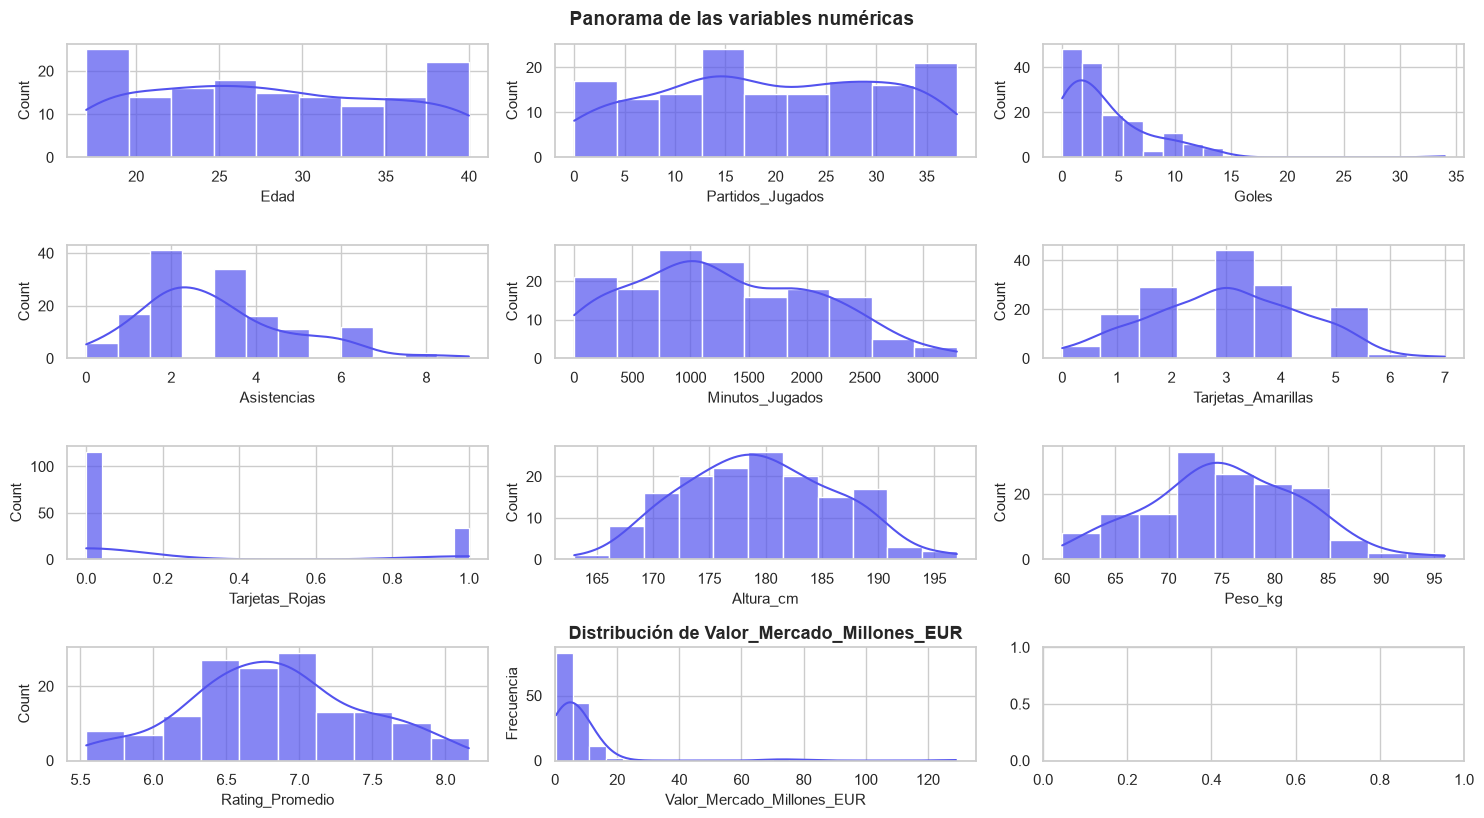

In [64]:
variables_num = ["Edad","Partidos_Jugados","Goles","Asistencias","Minutos_Jugados","Tarjetas_Amarillas","Tarjetas_Rojas","Altura_cm","Peso_kg","Rating_Promedio","Valor_Mercado_Millones_EUR"]

fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes = axes.flatten()

for i, var in enumerate(variables_num):sns.histplot(data=df, x=var, kde=True, ax=axes[i], color="#5353EE", alpha=0.7)
axes[i].set_title(f"Distribución de {var}")
axes[i].set_ylabel("Frecuencia")
axes[i].set_xlim(left=max(0, df[var].min() - 0.5))

plt.tight_layout()
plt.suptitle("Panorama de las variables numéricas", y=1.02, fontsize=14, fontweight="bold")
plt.show()


Detectando outliers visualmente

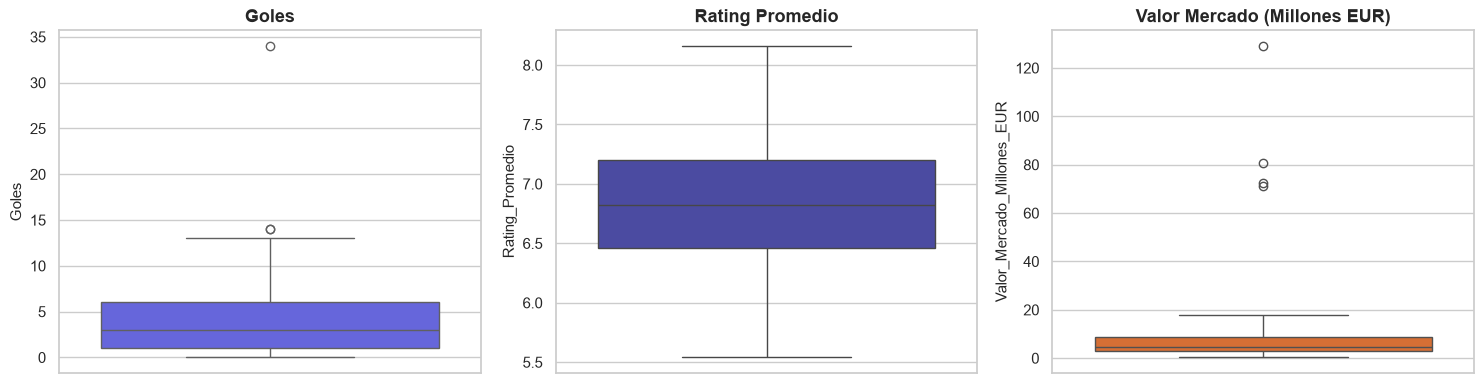

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df, y="Goles", ax=axes[0], color="#5353EE")
axes[0].set_title("Goles")

sns.boxplot(data=df, y="Rating_Promedio", ax=axes[1], color="#3D3DAF")
axes[1].set_title("Rating Promedio")

sns.boxplot(data=df, y="Valor_Mercado_Millones_EUR", ax=axes[2], color="#F0681A")
axes[2].set_title("Valor Mercado (Millones EUR)")

plt.tight_layout()
plt.show()

Distribucion de categoria principal 

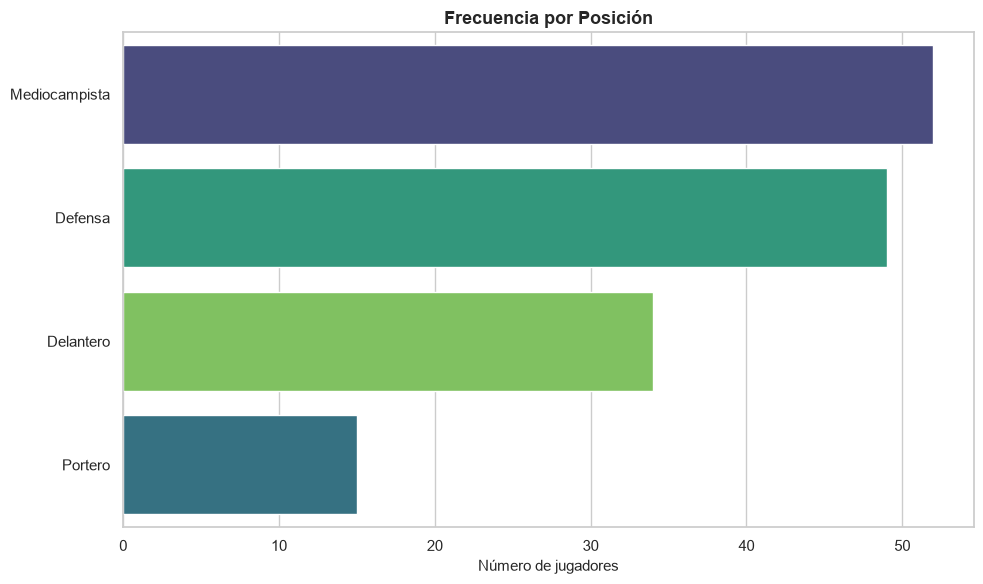

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

orden = df["Posicion"].value_counts().index

sns.countplot(data=df,y="Posicion",order=orden,ax=ax,palette="viridis",hue="Posicion",legend=False)

ax.set_title("Frecuencia por Posición")
ax.set_xlabel("Número de jugadores")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Analisis bi-variado

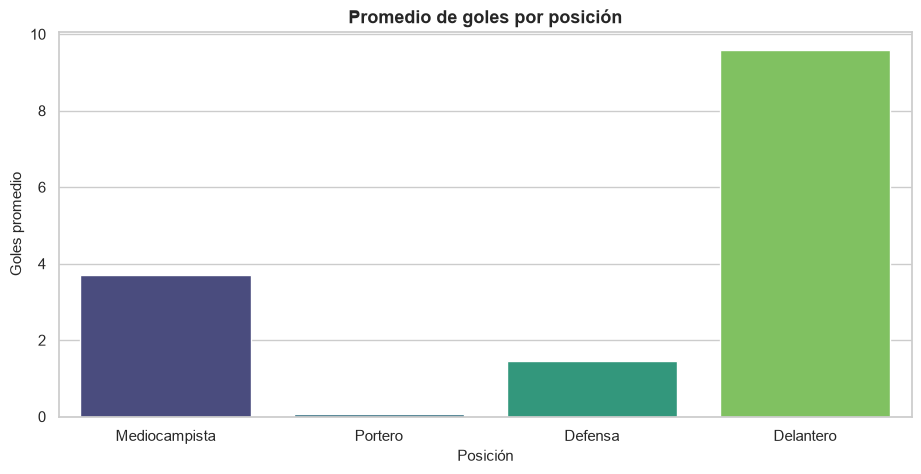

In [ ]:
plt.figure(figsize=(11, 5))

sns.barplot(data=df,x="Posicion",y="Goles",estimator="mean",errorbar=None,palette="viridis",hue="Posicion",legend=False)

plt.title("Promedio de goles por posición")
plt.xlabel("Posición")
plt.ylabel("Goles promedio")

plt.show()

Violinplot entre posicion y rating promedio

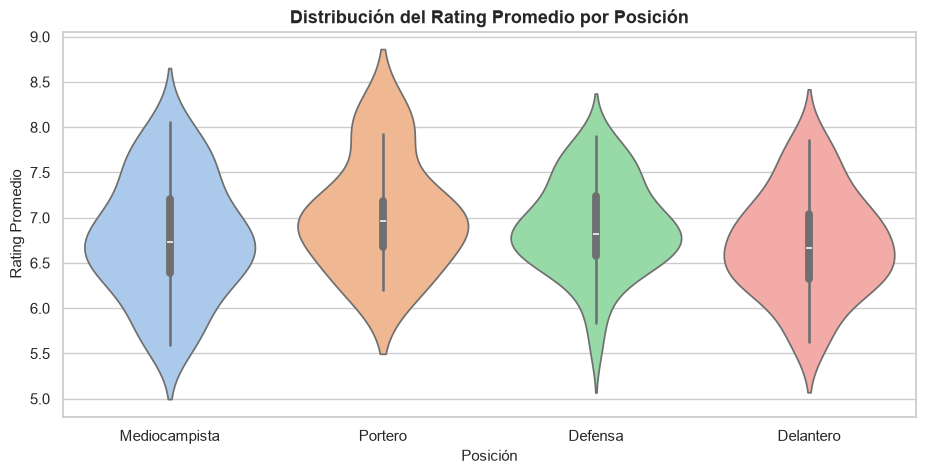

In [ ]:
plt.figure(figsize=(11, 5))

sns.violinplot(data=df,x="Posicion",y="Rating_Promedio",palette="pastel",hue="Posicion",legend=False)

plt.title("Distribución del Rating Promedio por Posición")
plt.xlabel("Posición")
plt.ylabel("Rating Promedio")

plt.show()

Analisis bivariado

In [51]:
tabla = pd.crosstab(df["Equipo"], df["Posicion"])
tabla

Posicion,Defensa,Delantero,Mediocampista,Portero
Equipo,,,,
Aguilas FC,5,4,4,2
Condores United,2,2,1,2
Delfines CF,4,3,7,1
Halcones CF,5,2,4,1
Jaguares SC,5,4,7,0
Leones United,6,2,4,1
Lobos FC,5,6,9,3
Panteras FC,9,4,5,1
Tigres SC,5,4,7,2


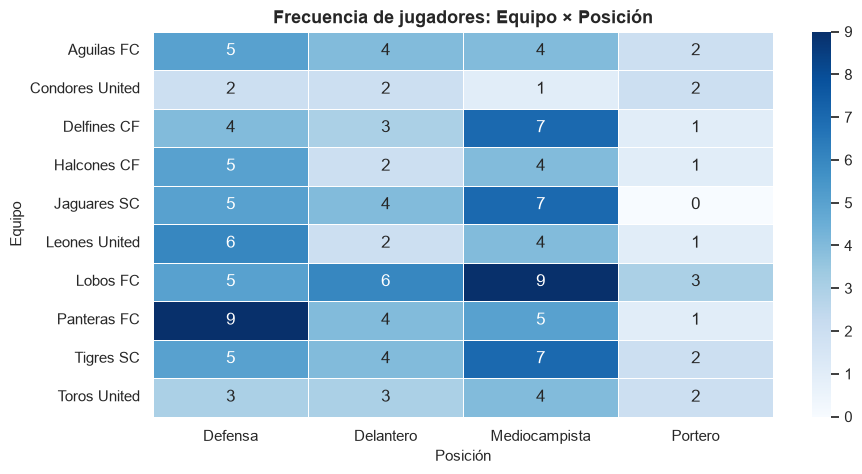

In [52]:
plt.figure(figsize=(10, 5))
sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Frecuencia de jugadores: Equipo × Posición")
plt.xlabel("Posición")
plt.ylabel("Equipo")
plt.show()

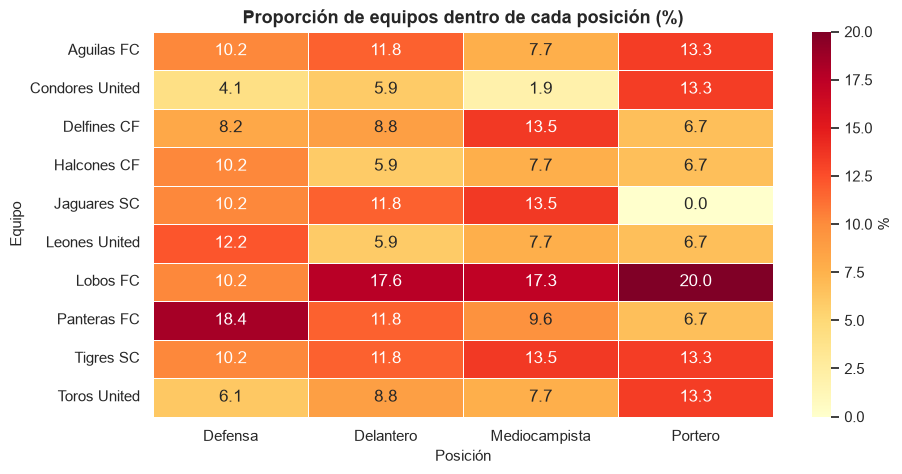

In [ ]:
tabla_prop = pd.crosstab(df["Equipo"], df["Posicion"], normalize="columns") * 100

plt.figure(figsize=(10, 5))
sns.heatmap(tabla_prop,annot=True,fmt=".1f",cmap="YlOrRd",linewidths=0.5,cbar_kws={"label": "%"})

plt.title("Proporción de equipos dentro de cada posición (%)")
plt.xlabel("Posición")
plt.ylabel("Equipo")

plt.show()

In [54]:
# Seleccionamos las variables numéricas
variables_corr = ["ID", "Edad", "Partidos_Jugados",
                  "Goles", "Asistencias", "Minutos_Jugados",
                  "Tarjetas_Amarillas", "Tarjetas_Rojas", "Altura_cm", "Peso_kg", "Rating_Promedio", "Valor_Mercado_Millones_EUR"]

matriz_corr = df[variables_corr].corr(method="pearson")
matriz_corr.round(2)

,ID,Edad,Partidos_Jugados,Goles,Asistencias,Minutos_Jugados,Tarjetas_Amarillas,Tarjetas_Rojas,Altura_cm,Peso_kg,Rating_Promedio,Valor_Mercado_Millones_EUR
ID,1.00,-0.05,0.01,-0.15,-0.04,0.04,-0.02,0.02,0.08,-0.05,0.09,-0.13
Edad,-0.05,1.00,-0.02,-0.15,-0.10,-0.01,-0.02,0.04,-0.02,0.03,0.05,-0.15
Partidos_Jugados,0.01,-0.02,1.00,-0.03,-0.03,0.89,-0.01,0.09,-0.01,-0.03,-0.01,0.05
Goles,-0.15,-0.15,-0.03,1.00,0.32,0.02,-0.06,0.01,0.09,-0.08,-0.13,0.60
Asistencias,-0.04,-0.10,-0.03,0.32,1.00,-0.03,0.06,-0.04,-0.12,0.06,0.05,0.25
Minutos_Jugados,0.04,-0.01,0.89,0.02,-0.03,1.00,-0.02,0.05,-0.08,-0.02,-0.05,0.10
Tarjetas_Amarillas,-0.02,-0.02,-0.01,-0.06,0.06,-0.02,1.00,-0.02,0.13,0.12,-0.10,-0.06
Tarjetas_Rojas,0.02,0.04,0.09,0.01,-0.04,0.05,-0.02,1.00,-0.09,-0.06,0.04,-0.00
Altura_cm,0.08,-0.02,-0.01,0.09,-0.12,-0.08,0.13,-0.09,1.00,0.09,0.01,-0.02
Peso_kg,-0.05,0.03,-0.03,-0.08,0.06,-0.02,0.12,-0.06,0.09,1.00,0.06,0.06


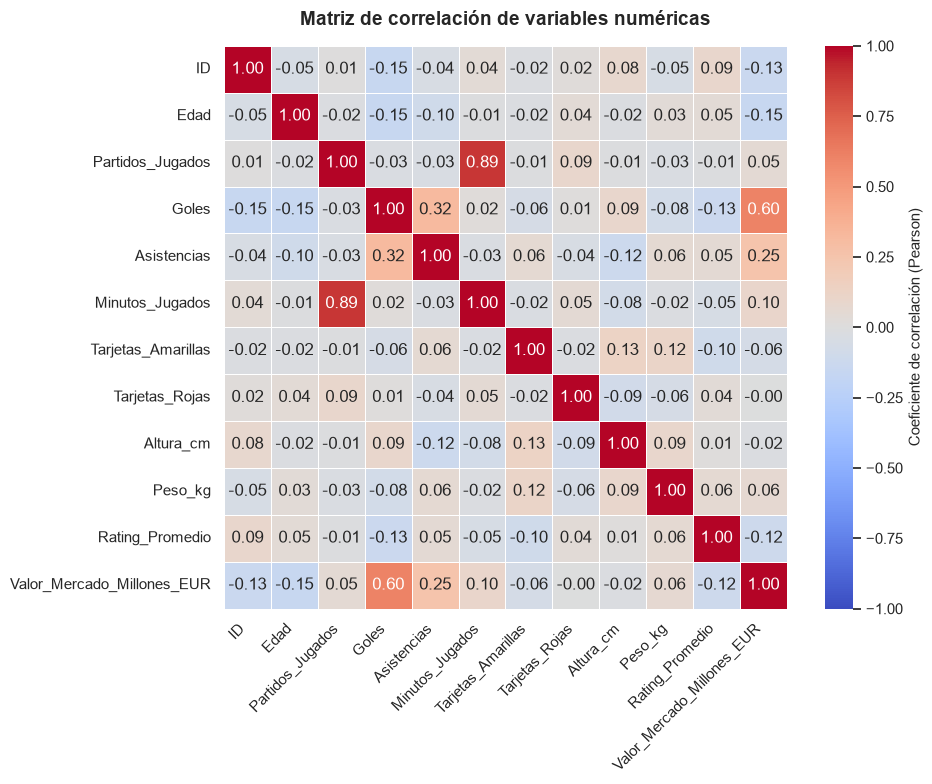

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr,annot=True,cmap="coolwarm",center=0,vmin=-1, vmax=1fmt=".2f",linewidths=0.5,square=True,cbar_kws={"label": "Coeficiente de correlación (Pearson)"},)
plt.title("Matriz de correlación de variables numéricas", fontsize=14, pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

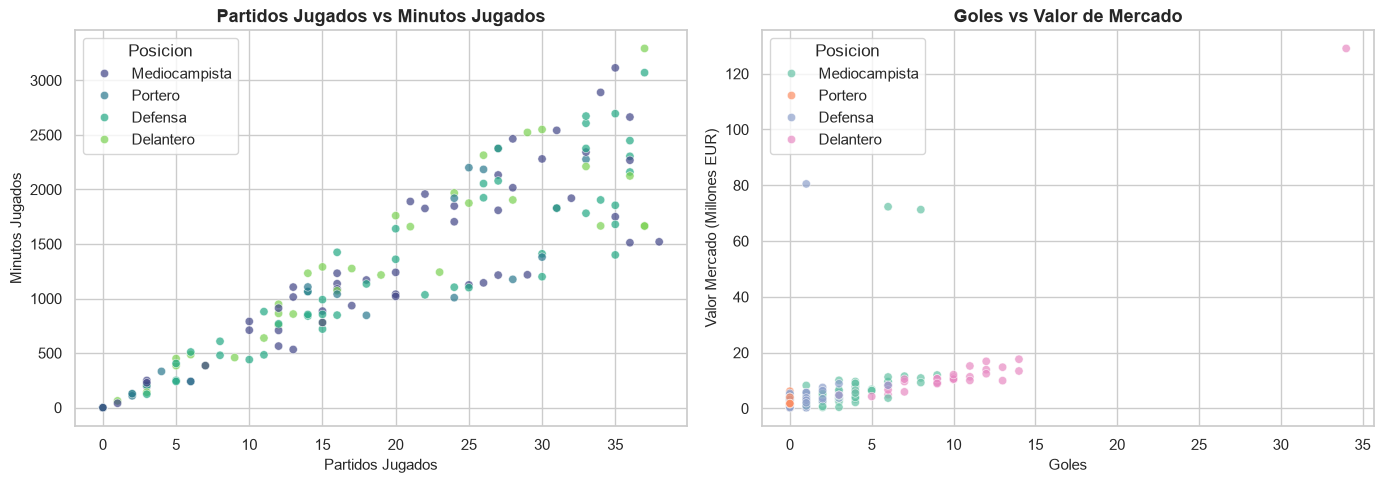

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.scatterplot(data=df,x="Partidos_Jugados",y="Minutos_Jugados",hue="Posicion",alpha=0.7,ax=axes[0],palette="viridis")

axes[0].set_title("Partidos Jugados vs Minutos Jugados")
axes[0].set_xlabel("Partidos Jugados")
axes[0].set_ylabel("Minutos Jugados")


sns.scatterplot(data=df,x="Goles",y="Valor_Mercado_Millones_EUR",hue="Posicion",alpha=0.7,ax=axes[1],palette="Set2")

axes[1].set_title("Goles vs Valor de Mercado")
axes[1].set_xlabel("Goles")
axes[1].set_ylabel("Valor Mercado (Millones EUR)")

plt.tight_layout()
plt.show()